In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'Sukuna.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(194, 259, 3)

In [3]:
def translation(tx, ty):
    return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float64)


def rotation(angle, c):
    a = np.deg2rad(angle)
    R = np.array([[np.cos(a), np.sin(a), 0], [-np.sin(a), np.cos(a), 0], [0, 0, 1]])
    return translation(*c) @ R @ translation(-c[0], -c[1])


def scaling(s, c):
    S = np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]], dtype=np.float64)
    return translation(*c) @ S @ translation(-c[0], -c[1])


def homography(src, dst):
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y])
        b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y])
        b.append(v)
    h = np.linalg.solve(np.array(A, dtype=np.float64), np.array(b, dtype=np.float64))
    return np.append(h, 1).reshape(3, 3)

In [4]:
wall = np.full((600, 800, 3), (200, 195, 185), dtype=np.uint8)
outer = np.int32([[410, 115], [710, 175], [710, 445], [410, 495]])
inner = np.float64([[430, 140], [690, 190], [690, 420], [430, 470]])
cv2.fillPoly(wall, [outer], (60, 40, 20))
cv2.fillPoly(wall, [np.int32(inner)], (235, 235, 230))


def paste(M):
    out = wall.copy()
    warped = cv2.warpPerspective(img, M, (800, 600))
    mask = cv2.warpPerspective(np.full(img.shape[:2], 255, dtype=np.uint8), M, (800, 600))
    out[mask > 0] = warped[mask > 0]
    return out

In [5]:
h, w = img.shape[:2]
corners = np.float64([[0, 0], [w, 0], [w, h], [0, h]])

S = scaling(0.7, (0, 0))

c = np.array([w * 0.7 / 2, h * 0.7 / 2])
Rigid = translation(*(np.array([230, 320]) - c)) @ rotation(10, c)

moved = np.hstack([corners, np.ones((4, 1))]) @ (Rigid @ S).T
moved = moved[:, :2] / moved[:, 2:]

P = homography(moved, inner)
M = P @ Rigid @ S

final = paste(M)
print(np.round(M, 4))

[[2.677700e+00 0.000000e+00 5.325359e+02]
 [6.341000e-01 2.106700e+00 1.733838e+02]
 [2.100000e-03 0.000000e+00 1.238500e+00]]


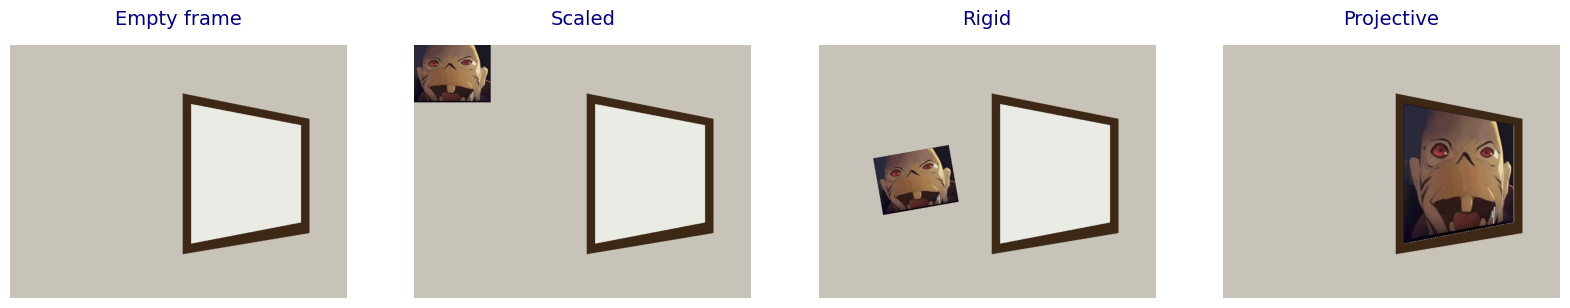

In [6]:
panels = [('Empty frame', wall), ('Scaled', paste(S)), ('Rigid', paste(Rigid @ S)), ('Projective', final)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task10_forger.png', cv2.cvtColor(final, cv2.COLOR_RGB2BGR))

True

Three steps from the hierarchy. Scale by 0.7 (linear, 2x2 part only) shrinks the painting, rigid (rotate 10 degrees and translate) moves it next to the frame without changing its shape, and the projective step warps its 4 corners onto the 4 corners of the picture area of the frame.

The homography is solved from the corners after the first two steps. All three are 3x3 so M = P @ Rigid @ S is a single matrix and the final image is warped from the original only once, which is better than resampling 3 times. The painting follows the angle of the frame, the right side is shorter than the left.